In [1]:
import sys
import os
from os.path import join
import glob
from copy import deepcopy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display, clear_output
from tqdm import tqdm

sys.path.insert(0, "../../ABC-SN/code")
import abcsn_config
import abcsn_training
import data_degrading as dg
import data_plotting as dplt
import data_preparation as dp
import preprocessing

sys.path.insert(0, "../code")
import review_spectrum as rs
import spectral_features as sf
import measure_signal as ms

from icecream import ic
from importlib import reload

2026-03-13 00:15:59.349859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
REPO_DIR = "../"
DATA_DIR = join(REPO_DIR, "data")

In [3]:
file_SNRmetadata = join(DATA_DIR, "forSNR", "SNRmetadata_nodupe.parquet")
file_data = join(DATA_DIR, "forSNR", "data_nodupe.parquet")
file_meta = join(DATA_DIR, "forSNR", "metadata_nodupe.parquet")
file_data_full = join(DATA_DIR, "forSNR", "data.parquet")
file_meta_full = join(DATA_DIR, "forSNR", "metadata.parquet")


df_SNRmetadata = pd.read_parquet(file_SNRmetadata)
df_data = pd.read_parquet(file_data)
df_meta = pd.read_parquet(file_meta)
df_data_full = pd.read_parquet(file_data_full)
df_meta_full = pd.read_parquet(file_meta_full)

In [4]:
df_SNRmetadata.shape, df_data.shape, df_meta.shape

((3625, 16), (3625, 1024), (3625, 6))

In [5]:
df_data_full.shape, df_meta_full.shape

((3764, 1024), (3764, 6))

In [6]:
wvl = df_data.columns.to_numpy().astype(float)

# 1. Check all skipped spectra had flat sections or another good reason to be excluded.

In [7]:
df_SNRmetadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3625 entries, 0 to 3624
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   SN Name              3625 non-null   category
 1   SN Subtype           3625 non-null   category
 2   SN Subtype ID        3625 non-null   int64   
 3   SN Maintype          3625 non-null   category
 4   SN Maintype ID       3625 non-null   int64   
 5   Spectral Phase       3625 non-null   float64 
 6   Denoising Parameter  3618 non-null   float64 
 7   minima_i             258 non-null    float64 
 8   searchBlu            3618 non-null   float64 
 9   searchRed            3618 non-null   float64 
 10  useBlu               3618 non-null   object  
 11  useRed               3618 non-null   object  
 12  maxBlu               3618 non-null   float64 
 13  maxRed               3618 non-null   float64 
 14  noiseWindowBlu       3618 non-null   float64 
 15  noiseWindowRed       

In [8]:
df_SNRmetadata["Denoising Parameter"].value_counts(dropna=False)

Denoising Parameter
 10.0     2251
 20.0      733
 15.0      328
-999.0     152
 30.0      151
 NaN         7
 25.0        2
 50.0        1
Name: count, dtype: int64

In [9]:
df_SNRmetadata.loc[0]

SN Name                sn2008ar
SN Subtype              Ia-norm
SN Subtype ID                 0
SN Maintype                  Ia
SN Maintype ID                0
Spectral Phase             -8.5
Denoising Parameter        15.0
minima_i                    NaN
searchBlu                 500.0
searchRed                   0.0
useBlu                     True
useRed                     True
maxBlu                      0.0
maxRed                      0.0
noiseWindowBlu            100.0
noiseWindowRed            100.0
Name: 0, dtype: object

In [10]:
def detect_flat_sections(wvl, spectrum, wvl_range=(4500, 7000)):
    wvl_mask = wvl >= 4500
    wvl_mask &= wvl <= 7000

    spectrum_diff = ~np.diff(spectrum, prepend=0).astype(bool)
    spectrum_diff &= wvl_mask
    return spectrum_diff

In [11]:
def measure_signal_algorithm(specsnr, options):
    specsnr.denoise_gaussian(options["Denoising Parameter"])
    specsnr.find_spectral_line(
        feature_search_bounds=(options["searchBlu"], options["searchRed"]),
        minima_i=options["minima_i"])
    specsnr.find_spectral_shoulders(
        blu_shoulder_nudge=options["maxBlu"].astype(int),
        red_shoulder_nudge=options["maxRed"].astype(int))
    specsnr.calc_pEW()
    specsnr.measure_feature_noise(
        noise_window_blu=options["noiseWindowBlu"],
        noise_window_red=options["noiseWindowRed"],
        useBlu=options["useBlu"],
        useRed=options["useRed"])
    specsnr.measure_SNR()
    return

In [12]:
def plot_with_SNR_stuff(specsnr, ax=None):
    if ax is None:
        fig, ax = plt.subplots(ncols=1, nrows=1, sharex=True, figsize=(6, 1))    
    ax.set_xlim((4500, 7000))
    ax.axis("off")
    
    # spectrum_diff_mask = detect_flat_sections(specsnr.wvl, specsnr.spectrum)
    # ax.fill_between(wvl, y1=1, y2=0, where=spectrum_diff_mask, alpha=0.5, color="tab:orange")
    
    ax.plot(wvl, specsnr.spectrum, c="k", lw=1)
    ax.plot(wvl, specsnr.signal, c="tab:blue")

    vertical_midpoint = np.sum(ax.get_ylim()) / 2
    horizontal_text_location = ax.get_xlim()[0]
    ax.text(
        horizontal_text_location, vertical_midpoint,
        f"{specsnr.name}\n{specsnr.subtype}\n{specsnr.phase} days",
        ha="right", va="center")

    horizontal_text_location = ax.get_xlim()[1]
    ax.text(
        horizontal_text_location, vertical_midpoint,
        f"SNR = {specsnr.SNR:.2f}\nS = {specsnr.S:.2e}\nN = {specsnr.N:.2e}\n$\sigma = {specsnr.denoising_parameter}$",
        ha="left", va="center")

    ax.plot(specsnr.pc_wvl, specsnr.pseudo_cont, c="tab:green")

    # Color in the regions used to calculate the noise on the red and blue
    # shoulders.
    if specsnr.useBlu:
        ax.fill_between(
            specsnr.wvl[specsnr.blu_inds],
            y1=1,
            y2=0,
            color="tab:blue",
            alpha=0.25)
        ax.fill_between(
            specsnr.wvl[specsnr.blu_inds],
            y1=1,
            y2=0,
            color="tab:blue",
            alpha=0.25)

    if specsnr.useRed:
        ax.fill_between(
            specsnr.wvl[specsnr.red_inds],
            y1=1,
            y2=0,
            color="tab:red",
            alpha=0.25)
        ax.fill_between(
            specsnr.wvl[specsnr.red_inds],
            y1=1,
            y2=0,
            color="tab:red",
            alpha=0.25)
    return

In [13]:
reload(ms)

SNRobjs = []
for i in tqdm(range(df_SNRmetadata.shape[0])):
    row_series = df_SNRmetadata.loc[i].copy(deep=True)
    sn_name = row_series["SN Name"]
    sn_subtype = row_series["SN Subtype"]
    sn_phase = row_series["Spectral Phase"]
    # print(sn_name, sn_subtype, sn_phase)

    if np.isnan(row_series["Denoising Parameter"]):
        continue
    elif row_series["Denoising Parameter"] == -999:
        continue

    mask = df_meta["SN Name"] == sn_name
    mask &= df_meta["Spectral Phase"] == sn_phase
    assert mask.sum() == 1
    spectrum = df_data[mask].to_numpy()
    assert spectrum.shape[0] == 1
    spectrum = spectrum[0]

    specsnr = ms.SpectrumSNR(
        sn_name,
        sn_subtype,
        sn_phase,
        wvl,
        spectrum)
    specsnr.summarize()
    specsnr.minmax_normalize()
    specsnr.set_spectral_feature()

    if np.isnan(row_series["minima_i"]):
        row_series["minima_i"] = None

    if row_series["Denoising Parameter"] == -999:
        continue
    elif np.isnan(row_series["Denoising Parameter"]):
        continue
    else:
        measure_signal_algorithm(specsnr, row_series)

    SNRobjs.append(specsnr)
    

 93%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▏       | 3382/3625 [04:15<00:17, 13.92it/s]

Finding emission shoulders.
Finding emission shoulders.
Finding emission shoulders.


 93%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▏       | 3384/3625 [04:15<00:18, 12.76it/s]

Finding emission shoulders.
Finding emission shoulders.
Finding emission shoulders.


 93%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▎       | 3388/3625 [04:16<00:19, 12.04it/s]

...

 99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ | 3597/3625 [04:32<00:02, 13.62it/s]

Finding emission shoulders.
Finding emission shoulders.
Finding emission shoulders.


 99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 3599/3625 [04:32<00:02, 12.31it/s]

Finding emission shoulders.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3625/3625 [04:35<00:00, 13.18it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 347/347 [02:27<00:00,  2.35it/s]


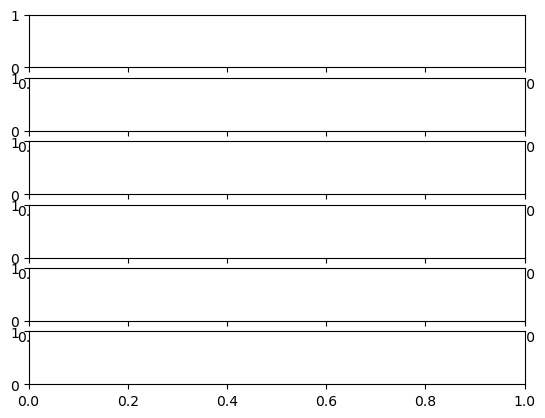

In [15]:
SNRobjs_argsort = np.argsort([specsnr.SNR for specsnr in SNRobjs])
SNRobjs_sorted = np.array(SNRobjs)[SNRobjs_argsort][::-1]

lines_per_fig = 10

num_spec = len(SNRobjs_sorted)
for i in tqdm(range(0, num_spec, lines_per_fig)):
    if i + lines_per_fig < num_spec:
        pass
    else:
        lines_per_fig = num_spec - i
        fig, axes = plt.subplots(ncols=1, nrows=lines_per_fig)

    fig, axes = plt.subplots(ncols=1, nrows=lines_per_fig, figsize=(6, lines_per_fig))
        
    for j in range(lines_per_fig):
        plot_with_SNR_stuff(SNRobjs_sorted[i+j], axes[j])

    fig.tight_layout()
    fig.savefig(f"../spectra_sparklines_SNRinfo/{i:0>5}")
    plt.close()